# Experiment 7 — Principal Component Analysis

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Data Set (Kaggle)

**Objective:** Standardize the features, perform PCA, identify the most important principal components, and determine how many components explain 95% of the variance.

> Kaggle setup: Add the dataset listed above to the notebook. The code automatically searches `/kaggle/input` for the required files/folders where possible.

In [1]:

import os, glob, warnings
warnings.filterwarnings("ignore")


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer

## 1. Load Breast Cancer Wisconsin data

In [3]:
# Try Kaggle CSV first; otherwise use sklearn's equivalent public dataset
paths = glob.glob("/kaggle/input/**/*.csv", recursive=True)
bc_paths = [p for p in paths if "breast" in p.lower() or "cancer" in p.lower() or "wisconsin" in p.lower()]

if bc_paths:
    path = bc_paths[0]
    df = pd.read_csv(path)
    print("Loaded Kaggle file:", path)
    display(df.head())
else:
    print("Kaggle CSV not found. Loading the equivalent Breast Cancer Wisconsin dataset from sklearn.")
    bunch = load_breast_cancer(as_frame=True)
    df = bunch.frame.copy()
    df["target"] = bunch.target

print("Shape:", df.shape)

Loaded Kaggle file: /kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Shape: (569, 33)


## 2. Standardize the numerical features

In [4]:
# Remove obvious identifier/target columns for PCA.
drop_cols = [c for c in df.columns if c.lower() in {"id","diagnosis","target","label"}]
X = df.drop(columns=drop_cols, errors="ignore")

# Keep numeric columns only.
X = X.select_dtypes(include=np.number).copy()
X = X.dropna(axis=1, how="all").fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features used:", len(X.columns))
print(X.columns.tolist())

Features used: 30
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


## 3. Apply PCA and identify the principal components

In [5]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

results = pd.DataFrame({
    "Principal Component": np.arange(1, len(explained)+1),
    "Explained Variance Ratio": explained,
    "Cumulative Variance": cumulative
})

display(results.head(10))
n95 = np.argmax(cumulative >= 0.95) + 1
print("Number of principal components needed for 95% variance:", n95)

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,1,0.442720,0.442720
1,2,0.189712,0.632432
2,3,0.093932,0.726364
3,4,0.066021,0.792385
4,5,0.054958,0.847343
5,6,0.040245,0.887588
6,7,0.022507,0.910095
7,8,0.015887,0.925983
8,9,0.013896,0.939879
9,10,0.011690,0.951569


Number of principal components needed for 95% variance: 10


## 4. Visualize explained variance

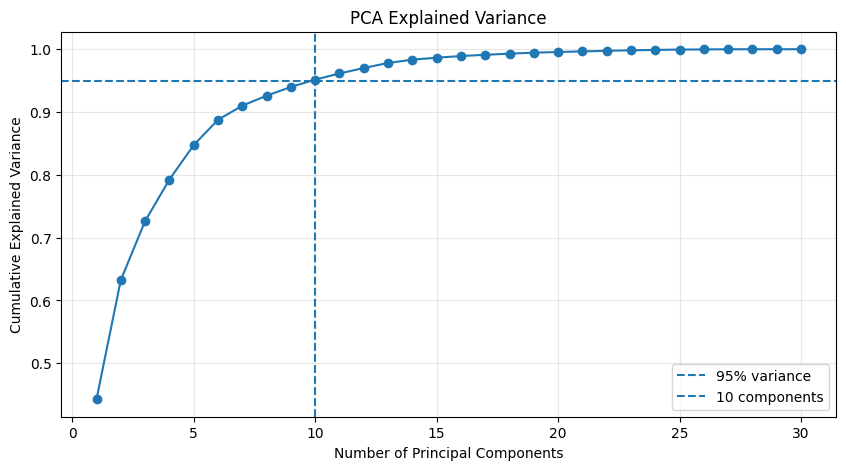

In [6]:
plt.figure(figsize=(10,5))
plt.plot(range(1, len(explained)+1), cumulative, marker="o")
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.axvline(n95, linestyle="--", label=f"{n95} components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. 2D PCA projection

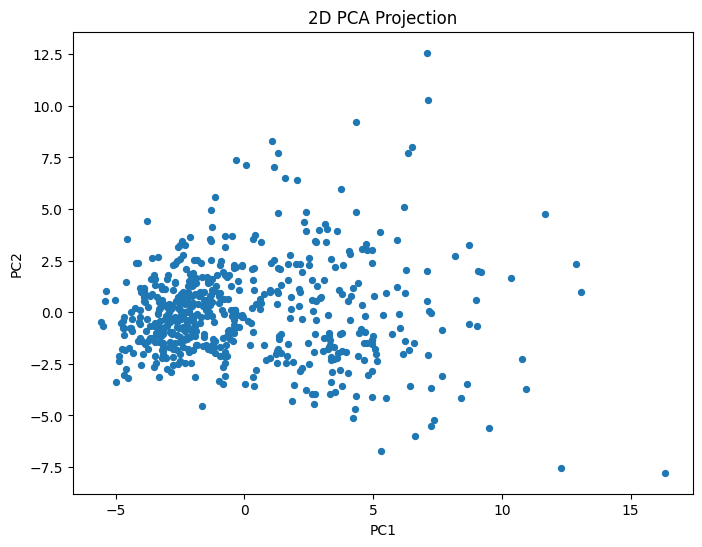

PC1 explains: 44.27 %
PC2 explains: 18.97 %


In [7]:
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], s=18)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.show()

print("PC1 explains:", round(pca2.explained_variance_ratio_[0]*100,2), "%")
print("PC2 explains:", round(pca2.explained_variance_ratio_[1]*100,2), "%")